In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('Customer Churn.csv')

In [3]:
data
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# replacing blanks with 0 as tenure is 0 and no total charges are recorded and converted datatype from object to float

In [5]:
data["TotalCharges"] = data["TotalCharges"].replace(" ","0")
data["TotalCharges"] = data["TotalCharges"].astype("float")

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
data.isnull().sum().sum()

0

In [8]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
data.duplicated().sum()

0

# converting dataframe for the seniorcitizen column to 'yes' or 'no'.

In [10]:
def conv(values):
    if values == 1:
        return "Yes"
    else:
        return "No"
data["SeniorCitizen"] = data["SeniorCitizen"].apply(conv)

In [11]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


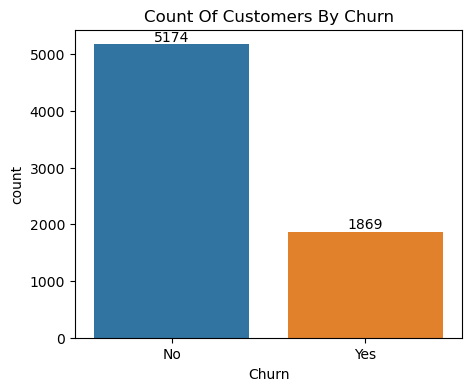

In [12]:
plt.figure(figsize = (5,4))

ax = sns.countplot(x = 'Churn',data = data)

ax.bar_label(ax.containers[0])

plt.title("Count Of Customers By Churn")
plt.show()

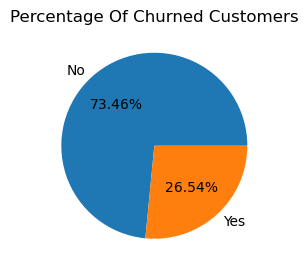

In [13]:
plt.figure(figsize = (3,4))
gb = data.groupby("Churn").agg({'Churn':"count"})

plt.pie(gb['Churn'],labels = gb.index,autopct = "%1.2f%%")

plt.title("Percentage Of Churned Customers")
plt.show()

# from the above pie chart we can conclude that 26.54% of our customers have churned out

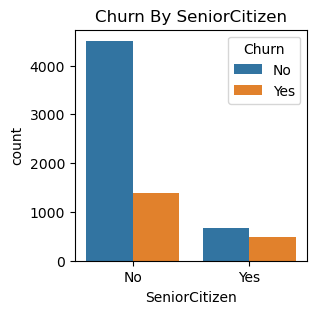

In [14]:
plt.figure(figsize = (3,3))

sns.countplot(x = "SeniorCitizen", data = data, hue = "Churn")

plt.title("Churn By SeniorCitizen")

plt.show()

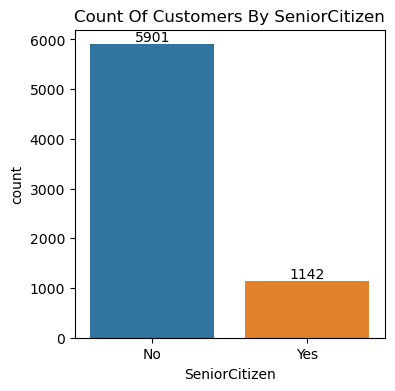

In [15]:
plt.figure(figsize = (4,4))

ax = sns.countplot(x = "SeniorCitizen", data = data)

ax.bar_label(ax.containers[0])

plt.title("Count Of Customers By SeniorCitizen")

plt.show()

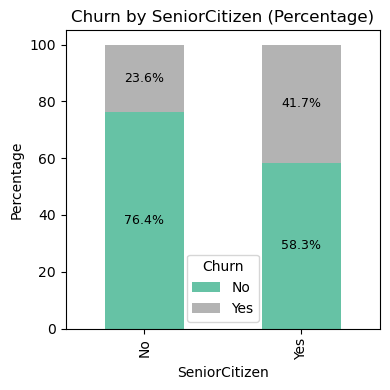

In [16]:
counts = pd.crosstab(data['SeniorCitizen'], data['Churn'])

# Step 2: Convert counts to percentages
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Step 3: Plot the stacked bar chart
ax = percentages.plot(kind='bar', stacked=True, figsize=(4, 4), colormap='Set2')

# Step 4: Add percentage labels on each bar
for i, row in enumerate(percentages.values):
    cumulative = 0
    for j, val in enumerate(row):
        if val > 0:
            ax.text(i, cumulative + val / 2, f'{val:.1f}%', ha='center', va='center', fontsize=9)
            cumulative += val

# Final touches
plt.title('Churn by SeniorCitizen (Percentage)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage')
plt.legend(title='Churn', loc='best')
plt.tight_layout()
plt.show()

# comparative a greater percentage of people in senior citizen category have churned

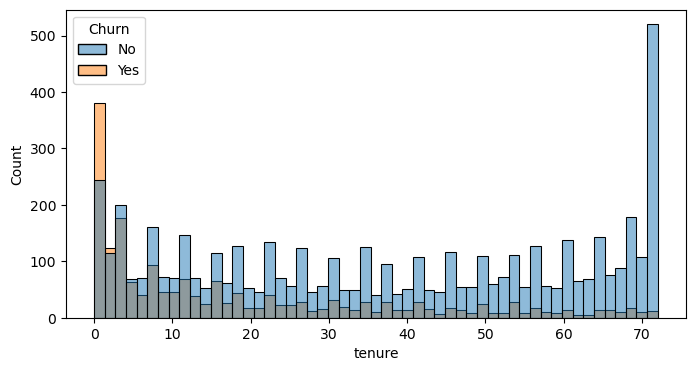

In [17]:
plt.figure(figsize = (8,4))

sns.histplot(x = "tenure", data = data, bins = 53, hue = "Churn")

plt.show()

# people who have used our services  for a long time have stayed and people who have used our services  #1 or 2 months have churned

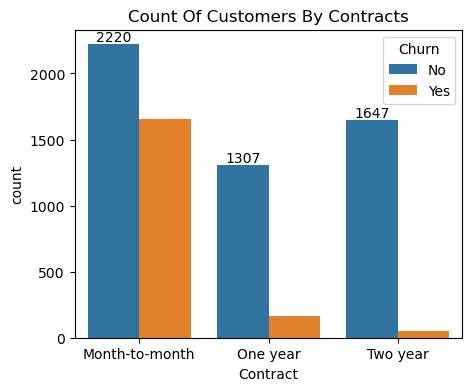

In [18]:
plt.figure(figsize = (5,4))

ax = sns.countplot(x = "Contract", data = data, hue = "Churn")

ax.bar_label(ax.containers[0])

plt.title("Count Of Customers By Contracts")

plt.show()

# people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract 

In [19]:
data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

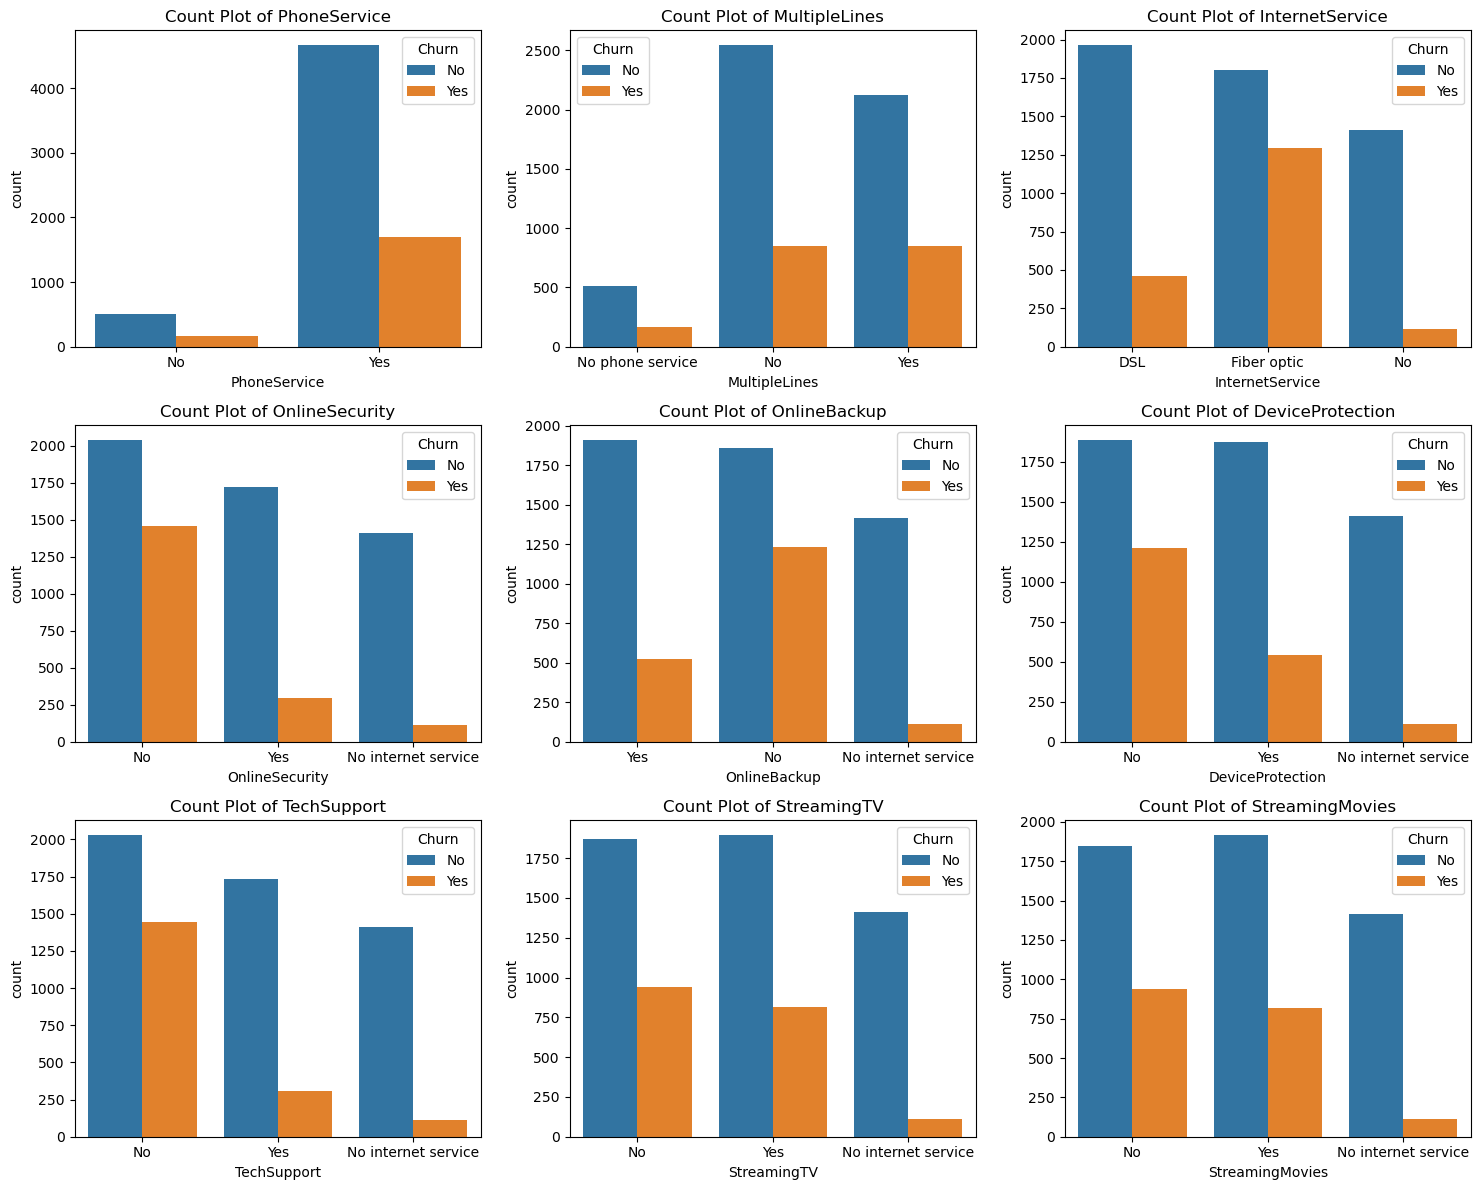

In [20]:

# List of columns to plot
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# Set up the grid size for subplots (3 rows x 3 columns for 9 features)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy indexing

# Create each countplot
for i, col in enumerate(cols):
    sns.countplot(data=data, x=col, hue = "Churn", ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation = 0)

# Adjust layout
plt.tight_layout()
plt.show()


# The visualizations show that customers who lack services like OnlineSecurity, TechSupport, and OnlineBackup tend to have higher churn rates, particularly among those with Fiber optic internet. In contrast, customers with PhoneService are less likely to churn

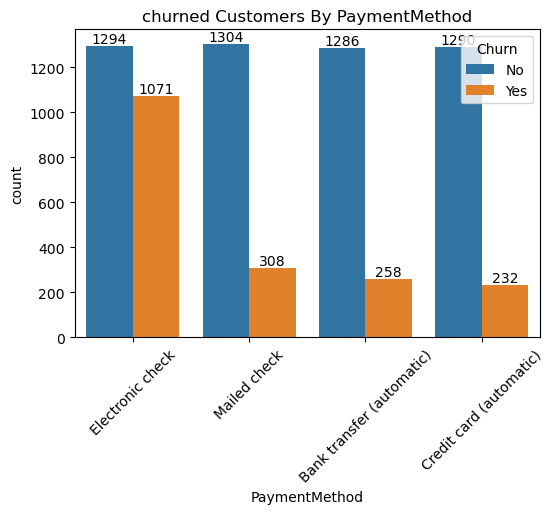

In [33]:
plt.figure(figsize = (6,4))

ax = sns.countplot(x = "PaymentMethod", data = data, hue = "Churn")

ax.bar_label(ax.containers[0])

ax.bar_label(ax.containers[1])

plt.title("churned Customers By PaymentMethod")

plt.xticks(rotation = 45)

plt.show()

# customer is likely to churn, when he is using electronic check as a payment method. 